Accuracy: 0.3333333333333333

Confusion Matrix:
 [[1 0]
 [2 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


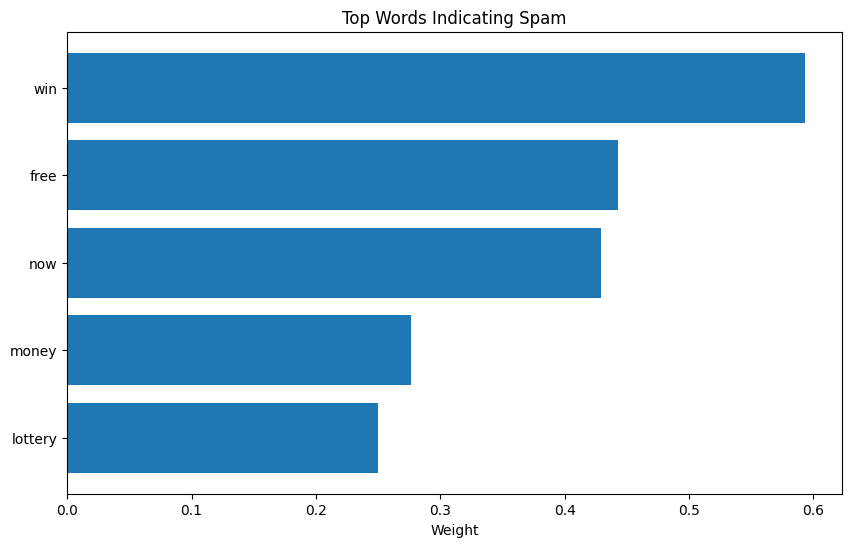


Email: 'win free money now'
Prediction: Spam
Spam Probability: 0.612

Email: 'project discussion tomorrow'
Prediction: Not Spam
Spam Probability: 0.305

Email: 'claim your free prize'
Prediction: Not Spam
Spam Probability: 0.453

Email: 'schedule the meeting'
Prediction: Not Spam
Spam Probability: 0.321


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

emails = [
    "win money now",
    "limited time offer",
    "meet me tomorrow",
    "project meeting schedule",
    "free lottery win",
    "let us discuss project",
    "win free cash now",
    "important project deadline",
    "claim your lottery prize",
    "team meeting tomorrow"
]

labels = np.array([1,1,0,0,1,0,1,0,1,0])

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(emails)
Y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

coefficients = model.coef_[0]
feature_names = vectorizer.get_feature_names_out()

top_spam_idx = np.argsort(coefficients)[-5:]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[top_spam_idx], coefficients[top_spam_idx])
plt.title("Top Words Indicating Spam")
plt.xlabel("Weight")
plt.show()

def predict_email(email):
    email_tfidf = vectorizer.transform([email])
    prediction = model.predict(email_tfidf)[0]
    probability = model.predict_proba(email_tfidf)[0][1]

    return prediction, probability


test_emails = [
    "win free money now",
    "project discussion tomorrow",
    "claim your free prize",
    "schedule the meeting"
]

for email in test_emails:
    pred, prob = predict_email(email)
    print(f"\nEmail: '{email}'")
    print("Prediction:", "Spam" if pred == 1 else "Not Spam")
    print("Spam Probability:", round(prob,3))